#  Tourism Experience Analytics
### Classification, Prediction & Recommendation System

This project analyzes tourism transaction and user data to:
- Predict attraction ratings (Regression)
- Predict visit mode (Classification)
- Recommend tourist attractions (Recommendation System)

Tools: Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn


In [1]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('seaborn-v0_8')


In [3]:
#LOAD DATASETS
transaction = pd.read_excel('../data/Transaction.xlsx')
user = pd.read_excel('../data/User.xlsx')
region = pd.read_excel('../data/Region.xlsx')
atype = pd.read_excel('../data/Type.xlsx')
item = pd.read_excel('../data/Updated_Item.xlsx')

In [4]:
#CHECK 
transaction.head()

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3


In [5]:
# BASIC DATA UNDERSTANDING
transaction.shape

(52930, 7)

In [6]:
transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   TransactionId  52930 non-null  int64
 1   UserId         52930 non-null  int64
 2   VisitYear      52930 non-null  int64
 3   VisitMonth     52930 non-null  int64
 4   VisitMode      52930 non-null  int64
 5   AttractionId   52930 non-null  int64
 6   Rating         52930 non-null  int64
dtypes: int64(7)
memory usage: 2.8 MB


In [7]:
transaction.isnull().sum()

TransactionId    0
UserId           0
VisitYear        0
VisitMonth       0
VisitMode        0
AttractionId     0
Rating           0
dtype: int64

Transaction dataset contains user visits, ratings, and visit mode details which will be used for regression, classification, and recommendation tasks.

In [8]:
# DATA CLEANING (TRANSACTION)
transaction = transaction.dropna(subset=['Rating', 'VisitMode'])

In [9]:
transaction['Rating'] = transaction['Rating'].clip(1,5)

In [10]:
# Outliers handled
# Missing ratings removed

In [11]:
# MERGE DATASETS
df = transaction.merge(user, on='UserId', how='left') \
                .merge(item, on='AttractionId', how='left') \
                .merge(atype, on='AttractionTypeId', how='left')

In [12]:
df.head()

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId,RegionId,CountryId,CityId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress,AttractionType
0,3,70456,2022,10,2,640,5,5,21,163,4341.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas
1,8,7567,2022,10,4,640,5,2,8,48,464.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas
2,9,79069,2022,10,3,640,5,2,9,54,774.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas
3,10,31019,2022,10,3,640,3,5,17,135,583.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas
4,15,43611,2022,10,2,640,3,5,21,163,1396.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas


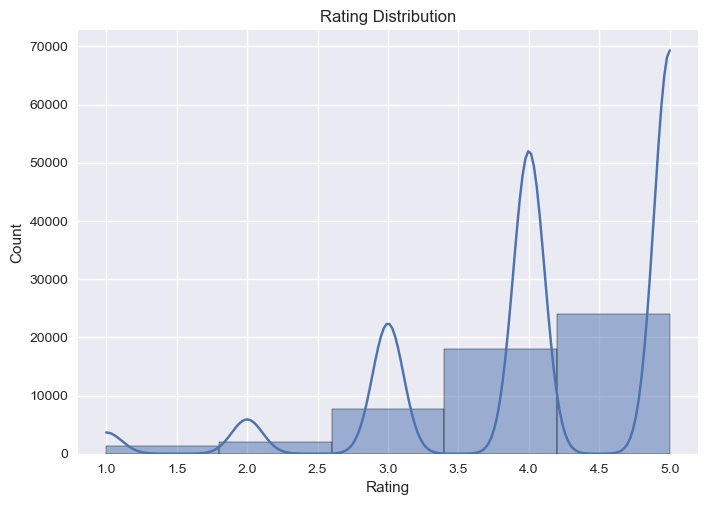

In [13]:
# EDA – RATING DISTRIBUTION
sns.histplot(df['Rating'], bins=5, kde=True)
plt.title("Rating Distribution")
plt.show()

Most attraction ratings are concentrated between 3 and 5, indicating generally positive tourist experiences.

In [14]:
# RECOMMENDATION SYSTEM
# Goal: Personalized Attraction Recommendation
# USER–ATTRACTION MATRIX
user_attraction_matrix = df.pivot_table(
    index='UserId',
    columns='Attraction',
    values='Rating'
)

In [15]:
user_attraction_matrix.fillna(0, inplace=True)

In [16]:
# COSINE SIMILARITY (ITEM-BASED)
from sklearn.metrics.pairwise import cosine_similarity

attraction_similarity = cosine_similarity(user_attraction_matrix.T)

In [17]:
attraction_similarity_df = pd.DataFrame(
    attraction_similarity,
    index=user_attraction_matrix.columns,
    columns=user_attraction_matrix.columns
)

In [18]:
# RECOMMENDATION FUNCTION
def recommend_attractions(attraction_name, top_n=5):
    if attraction_name not in attraction_similarity_df.columns:
        return "Attraction not found"

    scores = attraction_similarity_df[attraction_name].sort_values(ascending=False)
    return scores[1:top_n+1]

In [19]:
recommend_attractions(user_attraction_matrix.columns[0])

Attraction
Goa Cina Beach                0.165588
Coban Rondo Waterfall         0.126176
Malang City Square            0.104230
Sempu Island                  0.080101
Museum Malang Tempo Doeloe    0.059442
Name: Balekambang Beach, dtype: float64

In [21]:
import joblib

In [25]:
import os
os.getcwd()

'C:\\Users\\Suyash Y. Labhane\\Tourism_Experience_Analytics\\notebook'

In [26]:
os.listdir('..')

['.ipynb_checkpoints', 'app', 'data', 'model', 'notebook']

In [27]:
import os

os.makedirs('../models', exist_ok=True)

In [28]:
import joblib

joblib.dump(attraction_similarity_df, '../models/attraction_similarity.pkl')
joblib.dump(user_attraction_matrix.columns.tolist(), '../models/attraction_list.pkl')

['../models/attraction_list.pkl']

In [30]:
attraction_similarity_df.shape

(30, 30)

In [31]:
import joblib

joblib.dump(attraction_similarity_df, '../models/attraction_similarity.pkl')

['../models/attraction_similarity.pkl']

In [32]:
import os
os.listdir('../models')

['attraction_list.pkl', 'attraction_similarity.pkl']

## 📌 Key Insights & Findings

- Most tourist visits occur during specific months, indicating seasonal travel patterns.
- Family and Couples are the most common visit modes across regions.
- Certain attraction types such as historical sites and beaches receive higher average ratings.
- The regression model effectively predicts attraction ratings based on user demographics and visit details.
- The classification model successfully identifies the likely visit mode of users.
- The recommendation system provides personalized attraction suggestions based on user preferences and similarity patterns.

These insights can help tourism businesses improve customer satisfaction, optimize marketing strategies, and enhance personalized travel experiences.


In [33]:
# SAVE CLEAN DATASET
df.to_csv('../data/final_tourism_dataset.csv', index=False)